## Xenium QC Report Module

### Please enter the following information before running the notebook
1. uuid_list: If you are starting from a list of UUIDs, please add a comma separated list of UUIDs, where each UUID is within quotes.
2. project_short_name: Name of the project store where the aggregated file can be uploaded
3. title description for aggregated file output name
4. pdf_file_name: Filename for the pdf report of all visualizations
5. data_dir

In [1]:
import pandas as pd
import os
import datetime
import logging
import hisepy

In [2]:
# If you're reading from a directory
import os
data_dir = '/home/workspace/xenium/qc/EXP-02007-02008/csvs'
files = os.listdir(data_dir)
print(f"Files in directory: {files}")
print(f"Number of files: {len(files)}")

Files in directory: ['output-XETG00123__0095455__TSS10937-001__20260312__204727_metrics_summary.csv', 'output-XETG00123__0095455__TSS10546-009__20260312__204727_metrics_summary.csv', 'output-XETG00123__0095467__TSS10546-010__20260312__204727_metrics_summary.csv', 'output-XETG00123__0095455__TSS10938-003__20260312__204727_metrics_summary.csv', 'output-XETG00123__0095467__TSS10938-001__20260312__204727_metrics_summary.csv']
Number of files: 5


In [3]:
### Enter the path to metrics summary csv files if not entered above
output_dir = '/home/workspace/xenium/qc/EXP-02007-02008'

df_to_concat = []
run_name_list = []

if os.path.exists(data_dir):
        all_files = os.listdir(data_dir)

        # Filter for filenames ending with '.csv'
        csv_files = [filename for filename in all_files if filename.endswith('.csv')]
        for filename in csv_files:

            per_qc_report_path = os.path.join(data_dir, filename)

            df_per_sample_qc = pd.read_csv(per_qc_report_path)

            ## Get run names
            run_name = df_per_sample_qc.iloc[0]['run_name']
            run_name_list.append(run_name)

            df_to_concat.append(df_per_sample_qc)


df_aggregated_qc_report = pd.concat(df_to_concat)
    
output_qc_file_name = 'xenium_qc_report.csv'		

# Write the aggregated QC report dataframe to a .CSV file #
df_aggregated_qc_report.to_csv(os.path.join(output_dir, output_qc_file_name), index=False, header=True)

### Setting up data for visualizations

In [4]:
plot_df = df_aggregated_qc_report.dropna(axis=1, how='any')
plot_df

,run_name,cassette_name,region_name,panel_name,panel_design_id,region_area,total_cell_area,total_high_quality_decoded_transcripts,fraction_transcripts_decoded_q20,nuclear_transcripts_per_100um2,...,median_transcripts_per_cell,thickness_transcripts_high_quality,stain_definition,segmented_cell_stain_frac,segmented_cell_boundary_frac,segmented_cell_interior_frac,segmented_cell_nuc_expansion_frac,segmented_cell_boundary_count,segmented_cell_interior_count,segmented_cell_nuc_expansion_count
0,EXP-02007-02008,EXP-02007,TSS10937-001,mMulti_480g,TV46KD,3.203843e+07,1.173874e+07,32555683,0.898098,259.629828,...,103,7.546979,xenium_cell_segmentation_stains_v1,0.976619,0.238499,0.738120,0.023381,44669,138244,4379
0,EXP-02007-02008,EXP-02007,TSS10546-009,mMulti_480g,TV46KD,1.325627e+07,6.849860e+06,42540178,0.790464,618.451072,...,202,8.327843,xenium_cell_segmentation_stains_v1,0.990684,0.032638,0.958046,0.009316,6201,182024,1770
0,EXP-02007-02008,EXP-02008,TSS10546-010,mMulti_480g,TV46KD,1.369044e+07,6.663783e+06,46945190,0.722319,709.685659,...,232,7.808988,xenium_cell_segmentation_stains_v1,0.992993,0.010368,0.982625,0.007007,1900,180071,1284
0,EXP-02007-02008,EXP-02007,TSS10938-003,mMulti_480g,TV46KD,3.116766e+07,1.196299e+07,34472938,0.883832,277.198990,...,98,8.216604,xenium_cell_segmentation_stains_v1,0.970793,0.384751,0.586042,0.029207,79421,120972,6029
0,EXP-02007-02008,EXP-02008,TSS10938-001,mMulti_480g,TV46KD,1.082341e+08,3.573170e+07,151456314,0.908335,426.286550,...,175,8.491981,xenium_cell_segmentation_stains_v1,0.968895,0.227408,0.741487,0.031105,121510,396196,16620


In [5]:
run_name_list

['EXP-02007-02008',
 'EXP-02007-02008',
 'EXP-02007-02008',
 'EXP-02007-02008',
 'EXP-02007-02008']

In [6]:
plot_df.columns

Index(['run_name', 'cassette_name', 'region_name', 'panel_name',
       'panel_design_id', 'region_area', 'total_cell_area',
       'total_high_quality_decoded_transcripts',
       'fraction_transcripts_decoded_q20', 'nuclear_transcripts_per_100um2',
       'decoded_transcripts_per_100um2',
       'adjusted_negative_control_probe_rate',
       'adjusted_negative_control_codeword_rate',
       'negative_control_probe_counts_per_control_per_cell',
       'estimated_number_of_false_positive_transcripts_per_cell',
       'num_cells_detected', 'fraction_empty_cells', 'cells_per_100um2',
       'fraction_transcripts_assigned', 'median_genes_per_cell',
       'median_transcripts_per_cell', 'thickness_transcripts_high_quality',
       'stain_definition', 'segmented_cell_stain_frac',
       'segmented_cell_boundary_frac', 'segmented_cell_interior_frac',
       'segmented_cell_nuc_expansion_frac', 'segmented_cell_boundary_count',
       'segmented_cell_interior_count', 'segmented_cell_nuc_expans

In [7]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [8]:
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.backends.backend_pdf import PdfPages

In [9]:
colors = [
'#9e0142','#d53e4f','#f46d43','#fdae61','#fee08b','#e6f598','#abdda4','#66c2a5','#3288bd','#5e4fa2'
]

In [10]:
col = ['#d53e4f','#66c2a5','#5e4fa2']

In [11]:
pdf_pages = PdfPages('EXP-02007_02008_figs.pdf')

## Number of cells detected

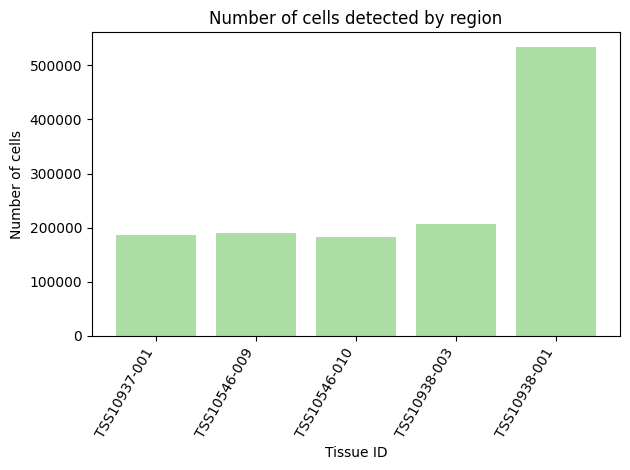

In [12]:
plt.bar(plot_df['region_name'], plot_df['num_cells_detected'], color= colors[6])
plt.xticks(rotation=60, ha = 'right')

# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('Number of cells')
plt.title('Number of cells detected by region')

plt.tight_layout()

pdf_pages.savefig()

## Transcripts and Genes per Tissue

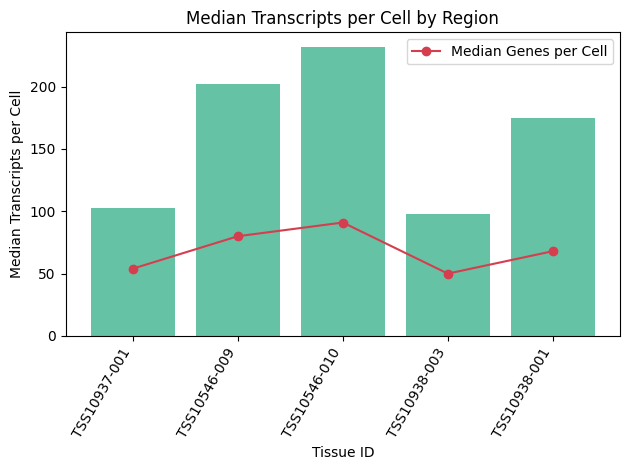

In [13]:
plt.bar(plot_df['region_name'], plot_df['median_transcripts_per_cell'], color= colors[7])
plt.xticks(rotation=60, ha = 'right')
plt.plot(plot_df['region_name'], plot_df['median_genes_per_cell'], color=colors[1], marker='o', label='Median Genes per Cell')

# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('Median Transcripts per Cell')
plt.title('Median Transcripts per Cell by Region')
plt.legend()

plt.tight_layout()

pdf_pages.savefig()

## Estimated False Positive Transcripts

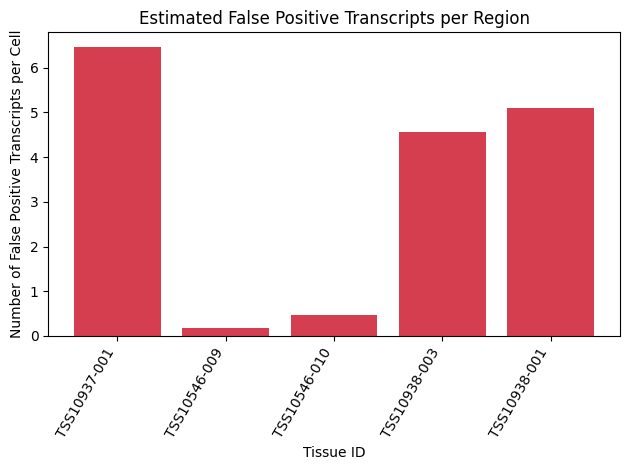

In [14]:
plt.bar(plot_df['region_name'], plot_df['estimated_number_of_false_positive_transcripts_per_cell'], color= colors[1])
plt.xticks(rotation=60, ha = 'right')
# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('Number of False Positive Transcripts per Cell')
plt.title('Estimated False Positive Transcripts per Region')

plt.tight_layout()

pdf_pages.savefig()

## Decoded Transcripts

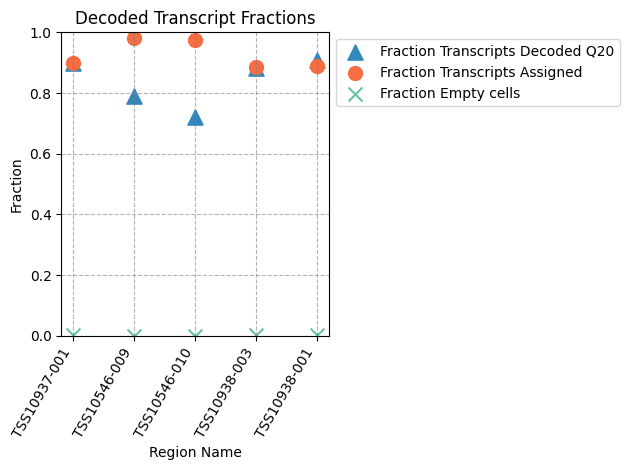

In [15]:
plt.scatter(plot_df['region_name'], plot_df['fraction_transcripts_decoded_q20'], color=colors[8], label='Fraction Transcripts Decoded Q20', marker='^', s=120)
plt.scatter(plot_df['region_name'], plot_df['fraction_transcripts_assigned'], color=colors[2], label='Fraction Transcripts Assigned', marker='o', s=100)
plt.scatter(plot_df['region_name'], plot_df['fraction_empty_cells'], color=colors[7], label='Fraction Empty cells', marker='x', s=100)
plt.xticks(rotation=60, ha='right')
plt.xlabel('Region Name')
plt.ylabel('Fraction')
plt.title('Decoded Transcript Fractions')
plt.ylim(0, 1)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', color='gray', alpha=0.6)

# Adjust layout to fit everything
plt.tight_layout()

pdf_pages.savefig()

## Cells per 100um sq

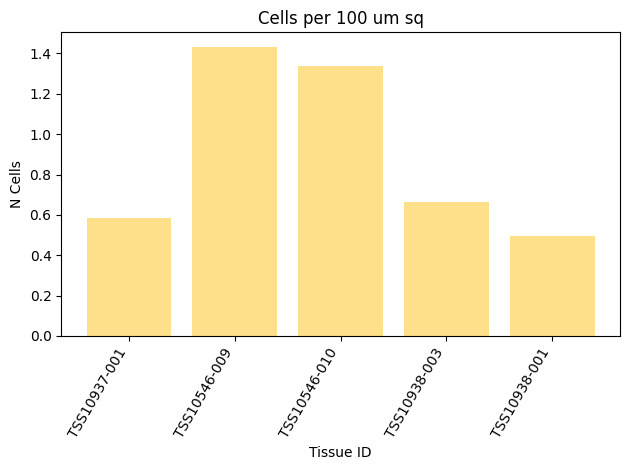

In [16]:
plt.bar(plot_df['region_name'], plot_df['cells_per_100um2'], color= colors[4])
plt.xticks(rotation=60, ha = 'right')

# Add labels and title
plt.xlabel('Tissue ID')
plt.ylabel('N Cells')
plt.title('Cells per 100 um sq')

plt.tight_layout()

pdf_pages.savefig()

## Segmentation Fractions and Counts

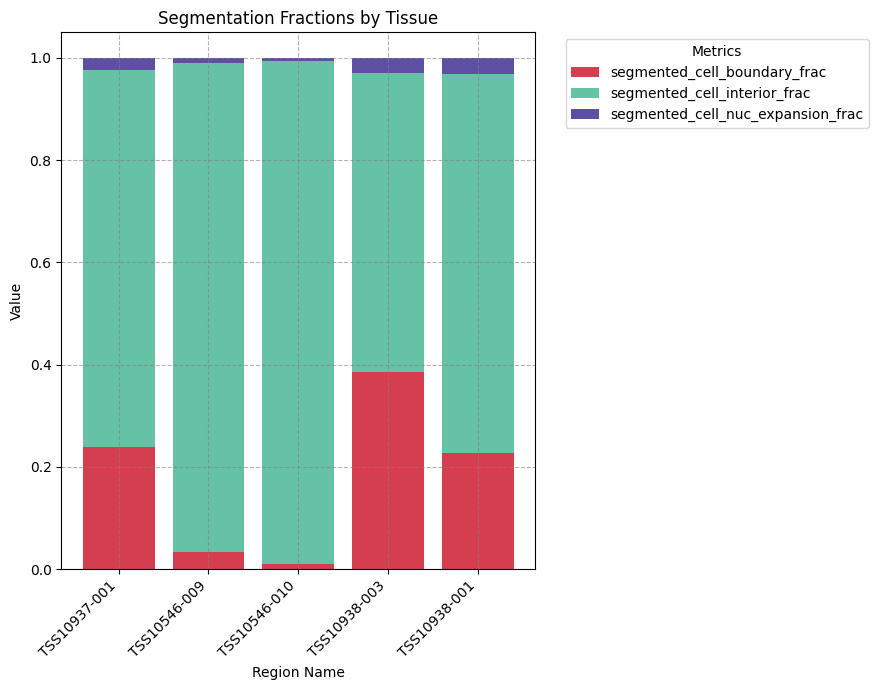

In [17]:
regions = plot_df['region_name']
values = plot_df[['segmented_cell_boundary_frac', 
                  'segmented_cell_interior_frac', 
                  'segmented_cell_nuc_expansion_frac']]

fig, ax = plt.subplots(figsize=(9, 7))

# Initialize the bottom position for stacking
bottoms = [0] * len(plot_df)

# Plot each stack
for i, column in enumerate(values.columns):
    ax.bar(
        regions,
        values[column],
        bottom=bottoms,
        label=column,
        color=col[i]
    )
    # Update the bottom position
    bottoms = [bottom + val for bottom, val in zip(bottoms, values[column])]

# Add labels and title
ax.set_xlabel('Region Name')
ax.set_ylabel('Value')
ax.set_title('Segmentation Fractions by Tissue')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show grid
plt.grid(True, linestyle='--', color='gray', alpha=0.6)

# Adjust layout to fit everything
plt.tight_layout()

pdf_pages.savefig()

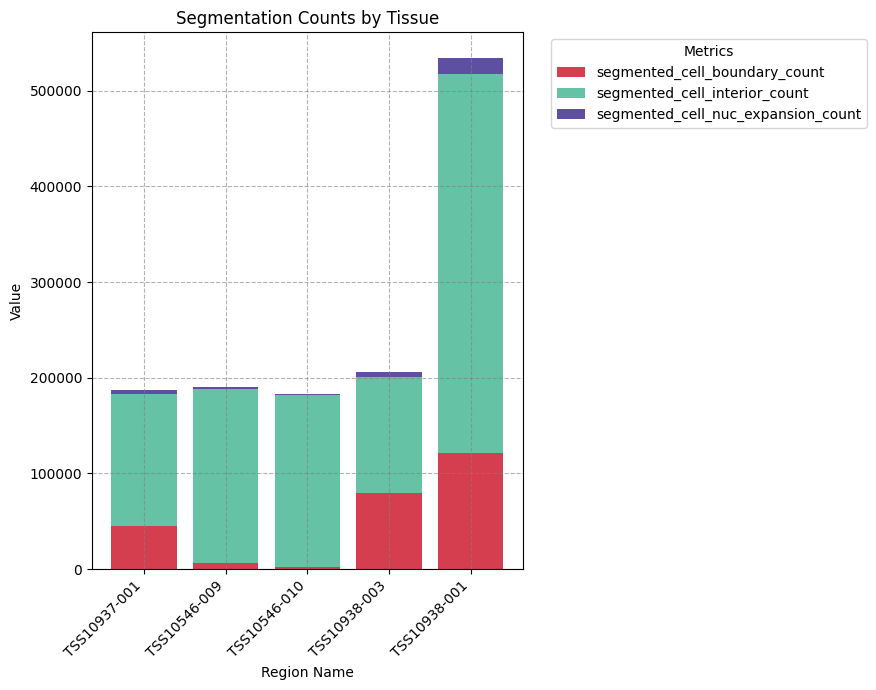

In [18]:
regions = plot_df['region_name']
values = plot_df[['segmented_cell_boundary_count', 
                  'segmented_cell_interior_count', 
                  'segmented_cell_nuc_expansion_count']]

fig, ax = plt.subplots(figsize=(9, 7))

# Initialize the bottom position for stacking
bottoms = [0] * len(plot_df)

# Plot each stack
for i, column in enumerate(values.columns):
    ax.bar(
        regions,
        values[column],
        bottom=bottoms,
        label=column,
        color=col[i]
    )
    # Update the bottom position
    bottoms = [bottom + val for bottom, val in zip(bottoms, values[column])]

# Add labels and title
ax.set_xlabel('Region Name')
ax.set_ylabel('Value')
ax.set_title('Segmentation Counts by Tissue')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show grid
plt.grid(True, linestyle='--', color='gray', alpha=0.6)

# Adjust layout to fit everything
plt.tight_layout()

pdf_pages.savefig()

## Median Transcripts per panel

/tmp/ipykernel_2883/424606040.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


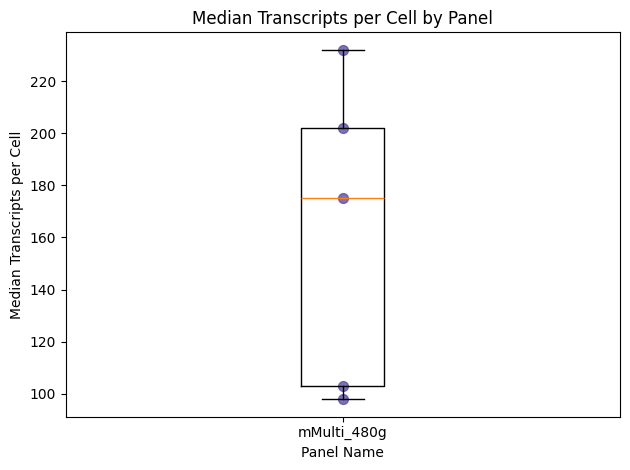

In [19]:
# Create the box plot
box = plt.boxplot(
    [plot_df[plot_df['panel_name'] == panel]['median_transcripts_per_cell'] for panel in plot_df['panel_name'].unique()],
    labels=plot_df['panel_name'].unique(),
    showfliers=False 
)
# Overlay individual points
for i, panel in enumerate(plot_df['panel_name'].unique(), start=1):
    # Extract data for the current panel
    panel_data = plot_df[plot_df['panel_name'] == panel]['median_transcripts_per_cell']
    
    # Scatter plot on top of box plot
    plt.scatter(
        [i] * len(panel_data),  
        panel_data,             
        color= colors[9],          
        alpha=0.8,           
        s=50,                 
        label=f'Points in {panel}' if i == 1 else "_" 
    )
# Labeling
plt.xlabel('Panel Name')
plt.ylabel('Median Transcripts per Cell')
plt.title('Median Transcripts per Cell by Panel')

plt.tight_layout()

pdf_pages.savefig()

In [20]:

plt.close()
pdf_pages.close()